### "RecomS6" Project - Recommendation System with 6 different algorythms

Importing some libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv('/content/drive/MyDrive/archive/rating.csv')


In [3]:
ratings

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40
...,...,...,...,...
20000258,138493,68954,4.5,2009-11-13 15:42:00
20000259,138493,69526,4.5,2009-12-03 18:31:48
20000260,138493,69644,3.0,2009-12-07 18:10:57
20000261,138493,70286,5.0,2009-11-13 15:42:24


## Data Cleaning

### Dropping 1995 Ratings
MovieLens had just launched in 1995, leaving us with a grand total of 4 ratings
that year. Hardly a representative sample. Beyond being statistically useless,
keeping it risked corrupting the temporal split for any user active that early —
so we cut it without hesitation.

In [ ]:
# Drop 1995 ratings
ratings['date'] = pd.to_datetime(ratings['timestamp'])
ratings['year'] = ratings['date'].dt.year
ratings = ratings[ratings['year'] != 1995]
ratings = ratings.drop(columns=['date', 'year'])

### Dropping Movies with Less Than 10 Ratings
This one looked scary on paper — we dropped 41% of all movies. But when we
checked how many ratings those movies actually represented, the answer was 0.18%.
That's the long tail problem in action: thousands of obscure titles collectively
generating almost no signal whatsoever. Collaborative filtering simply cannot
learn anything useful from a movie rated 3 times in 20 years. We chopped the
thinnest part of the tail and kept 99.82% of all rating activity intact.

Worth noting — these movies are only excluded from the ratings data. Their genome
scores and tag metadata stay available for content-based approaches, where they
might still get a fighting chance.

In [16]:
# Chop the thin tail — movies with less than 10 ratings
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
valid_movies = ratings_per_movie[ratings_per_movie >= 10].index
ratings = ratings[ratings['movieId'].isin(valid_movies)]

print(f"Final ratings count: {len(ratings):,}")
print(f"Final unique users: {ratings['userId'].nunique():,}")
print(f"Final unique movies: {ratings['movieId'].nunique():,}")

Final ratings count: 19,964,829
Final unique users: 138,493
Final unique movies: 15,451


## Train/Test Split

Splitting a recommendation dataset isn't as straightforward as a typical
80/20 random split. Randomly shuffling would leak future behavior into training —
the model would essentially be allowed to "remember" things it shouldn't know yet.

Instead we split per user by timestamp — each user's rating history is sorted
chronologically and the last 20% of their personal timeline goes to the test set.
This way the model only ever learns from what a user did in the past, and gets
evaluated on whether it can predict what they did next.

A global date cutoff would've been unfair — some users were active in 1998,
others mostly in 2013. A single cutoff date treats them very differently.
Per-user split gives everyone a proportional and fair evaluation window.

In [17]:
def split_user_ratings(user_df):
    user_df = user_df.sort_values('timestamp')
    split_idx = int(len(user_df) * 0.8)
    return user_df.iloc[:split_idx], user_df.iloc[split_idx:]

train_list, test_list = [], []

for user_id, user_df in ratings.groupby('userId'):
    train, test = split_user_ratings(user_df)
    train_list.append(train)
    test_list.append(test)

train_ratings = pd.concat(train_list).reset_index(drop=True)
test_ratings = pd.concat(test_list).reset_index(drop=True)

In [5]:
test_ratings.shape, train_ratings.shape

((4054451, 4), (15945812, 4))

Saving them as csv files for future reference

In [18]:
# Save to Google Drive
base_path = '/content/drive/MyDrive/archive/'

train_ratings.to_csv(base_path + 'train_ratings.csv', index=False)
test_ratings.to_csv(base_path + 'test_ratings.csv', index=False)

print(f"Train set: {train_ratings.shape[0]:,} ratings")
print(f"Test set: {test_ratings.shape[0]:,} ratings")
print(f"Train/Test ratio: {train_ratings.shape[0]/len(ratings)*100:.1f}% / {test_ratings.shape[0]/len(ratings)*100:.1f}%")

Train set: 15,917,423 ratings
Test set: 4,047,406 ratings
Train/Test ratio: 79.7% / 20.3%


In [6]:
user_sample = ratings[ratings['userId'] == 1].sort_values('timestamp')
train_sample = train_ratings[train_ratings['userId'] == 1]
test_sample = test_ratings[test_ratings['userId'] == 1]

print(f"User 1 total ratings: {len(user_sample)}")
print(f"User 1 train: {len(train_sample)}")
print(f"User 1 test: {len(test_sample)}")

print("\nLast train timestamp:", train_sample['timestamp'].max())
print("First test timestamp:", test_sample['timestamp'].min())

User 1 total ratings: 175
User 1 train: 140
User 1 test: 35

Last train timestamp: 2005-04-02 23:51:45
First test timestamp: 2005-04-02 23:52:03


## Rating Distribution

First thing that jumps out — this data is heavily biased toward positive ratings.
4★ leads the pack at 27.8%, followed by 3★ at 21.5% and 5★ at 14.5%.
Together, ratings of 3★ and above account for 82.4% of all activity.

This is classic positive selection bias — people tend to rate movies they
chose to watch, and they tend to choose movies they expect to enjoy.
Nobody queues up a film they think they'll hate just to rate it poorly.

The mean rating sits at 3.53, which becomes our natural relevance threshold.
Any movie a user rated at 3.5★ or above we consider a genuine recommendation
— this is the cutoff we'll use for Precision@K and Recall@K evaluation later.

One more thing worth noting — MovieLens uses half-star increments rather than
whole stars. Some algorithms assume integer ratings, so this is something to
keep in mind when implementing and comparing across different approaches.

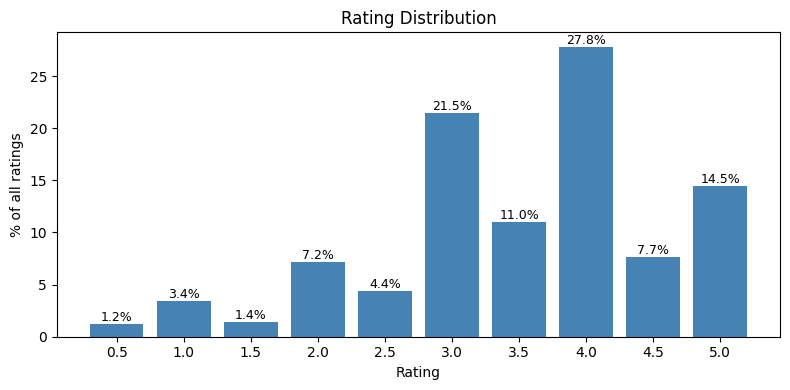

rating
0.5     1.195609
1.0     3.403615
1.5     1.396242
2.0     7.154891
2.5     4.416932
3.0    21.455683
3.5    11.000635
4.0    27.809264
4.5     7.674019
5.0    14.493109
Name: proportion, dtype: float64


In [7]:
rating_dist = ratings['rating'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 4))
plt.bar(rating_dist.index, rating_dist.values, color='steelblue', width=0.4)
plt.xlabel('Rating')
plt.ylabel('% of all ratings')
plt.title('Rating Distribution')
plt.xticks(rating_dist.index)
for i, v in zip(rating_dist.index, rating_dist.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(rating_dist)

In [8]:
print(f"Mean rating: {ratings['rating'].mean():.2f}")

Mean rating: 3.53


## User Activity Distribution

The gap between mean (144) and median (68) already tells the story —
a small number of extremely active users are pulling the average up dramatically.
Someone out there rated 9,254 movies. That's essentially the entire catalogue.

Breaking it down further:
- 38% of users have less than 50 ratings — casual visitors
- 57% fall in the moderate range of 50-500 ratings — your typical user
- Only 5% have 500+ ratings — power users
- A mere 1.4% crossed the 1000 rating mark — the obsessives

This distribution matters for algorithm performance. Collaborative filtering
and SVD thrive on rich rating histories — they'll do well on moderate and power
users but struggle with the casual 38%. This is partly why we're not relying
on a single algorithm. The graph approach, backed by genre and tag connections,
can still find meaningful recommendations for users with thinner histories
where pure rating-based methods start to fall apart.

Min ratings per user: 20
Max ratings per user: 9254
Mean ratings per user: 144.4
Median ratings per user: 68.0


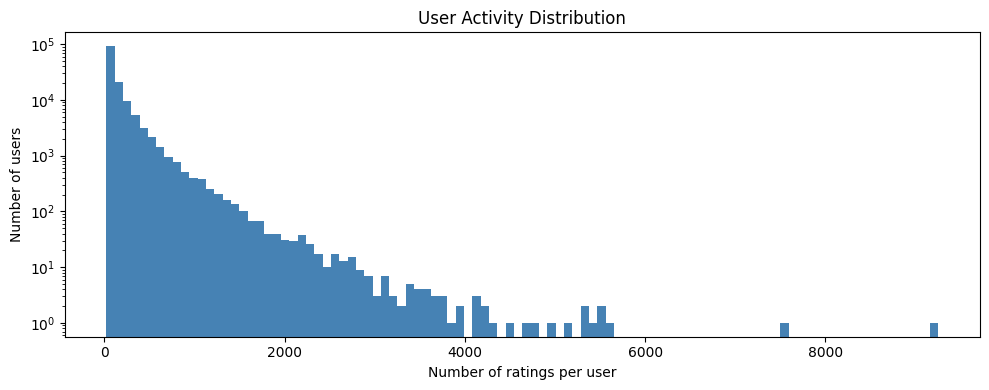

In [9]:
ratings_per_user = ratings.groupby('userId')['rating'].count()

print(f"Min ratings per user: {ratings_per_user.min()}")
print(f"Max ratings per user: {ratings_per_user.max()}")
print(f"Mean ratings per user: {ratings_per_user.mean():.1f}")
print(f"Median ratings per user: {ratings_per_user.median():.1f}")

plt.figure(figsize=(10, 4))
plt.hist(ratings_per_user, bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Number of ratings per user')
plt.ylabel('Number of users')
plt.title('User Activity Distribution')
plt.yscale('log')  # log scale because distribution is heavily skewed
plt.tight_layout()
plt.show()

In [10]:
print(f"Users with less than 50 ratings: {(ratings_per_user < 50).sum()}")
print(f"Users with more than 500 ratings: {(ratings_per_user > 500).sum()}")
print(f"Users with more than 1000 ratings: {(ratings_per_user > 1000).sum()}")

Users with less than 50 ratings: 53186
Users with more than 500 ratings: 7441
Users with more than 1000 ratings: 1884


## Movie Popularity Distribution

If the user activity distribution looked skewed, this one is on another level entirely.
Mean of 748 versus median of 18 — that's a 40x gap. Compare that to users
where the gap was roughly 2x. Something very different is happening here.

One movie collected 67,310 ratings. Meanwhile 59% of the entire catalogue
never crossed 50 ratings in 20 years of platform history. That's the long tail
problem laid completely bare — a handful of blockbusters absorbing the vast
majority of all rating activity while thousands of films drown in obscurity.

The numbers make it concrete:
- 59% of movies have less than 50 ratings
- Only 11% crossed 1000 ratings
- 462 movies have 10,000+ ratings

This is the core challenge my project is built around. Algorithms trained on
this data will naturally keep recommending the same popular films over and over —
not because they're the best match, but because they have the most signal.
Obscure films with rich genome scores and strong tag connections deserve a
fighting chance too, which is exactly where the graph and content-based
approaches come in.

Min ratings per movie: 1
Max ratings per movie: 67310
Mean ratings per movie: 747.8
Median ratings per movie: 18.0

Movies with less than 10 ratings: 11293
Movies with less than 50 ratings: 16220
Movies with more than 1000 ratings: 3159
Movies with more than 10000 ratings: 462


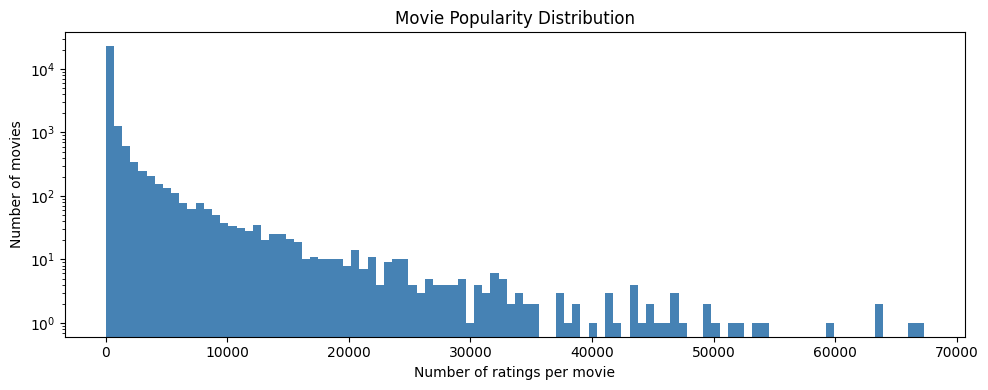

In [11]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

print(f"Min ratings per movie: {ratings_per_movie.min()}")
print(f"Max ratings per movie: {ratings_per_movie.max()}")
print(f"Mean ratings per movie: {ratings_per_movie.mean():.1f}")
print(f"Median ratings per movie: {ratings_per_movie.median():.1f}")

print(f"\nMovies with less than 10 ratings: {(ratings_per_movie < 10).sum()}")
print(f"Movies with less than 50 ratings: {(ratings_per_movie < 50).sum()}")
print(f"Movies with more than 1000 ratings: {(ratings_per_movie > 1000).sum()}")
print(f"Movies with more than 10000 ratings: {(ratings_per_movie > 10000).sum()}")

plt.figure(figsize=(10, 4))
plt.hist(ratings_per_movie, bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Number of ratings per movie')
plt.ylabel('Number of movies')
plt.title('Movie Popularity Distribution')
plt.yscale('log')
plt.tight_layout()
plt.show()

## Matrix Sparsity

Here's where the true scale of the problem becomes visible.

138,493 users. 26,744 movies. If every user rated every movie we'd have
3.7 billion data points to work with. Instead we have 20 million — meaning
99.46% of the entire user-movie matrix is completely empty.

In [12]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Total ratings: {n_ratings:,}")
print(f"Total possible ratings: {total_possible:,}")
print(f"Sparsity: {sparsity:.4%}")
print(f"Density: {1-sparsity:.4%}")

Users: 138,493
Movies: 26,744
Total ratings: 20,000,263
Total possible ratings: 3,703,856,792
Sparsity: 99.4600%
Density: 0.5400%


## Ratings Over Time

Two clear peaks — 2000 and 2005 — both followed by gradual decline as Netflix,
IMDb and other platforms began absorbing movie rating activity that MovieLens
once captured alone. By 2015 activity had dropped to its lowest since the late 90s.

1995 stands out immediately — 4 ratings for the entire year. MovieLens had just
launched and was barely alive. We dropped it entirely for this reason.

The steady decline post-2005 is worth keeping in mind during evaluation —
our training data is heavily weighted toward the early 2000s, while test sets
will reflect 2010s viewing behavior. Tastes and available content shifted
considerably across that gap, making our evaluation harder but more realistic.

year
1995          4
1996    1612609
1997     700982
1998     308070
1999    1198384
2000    1953659
2001    1186125
2002     869719
2003    1035878
2004    1170049
2005    1803158
2006    1171836
2007    1053430
2008    1158777
2009     930036
2010     903691
2011     766366
2012     731389
2013     599327
2014     562888
2015     283886
Name: rating, dtype: int64


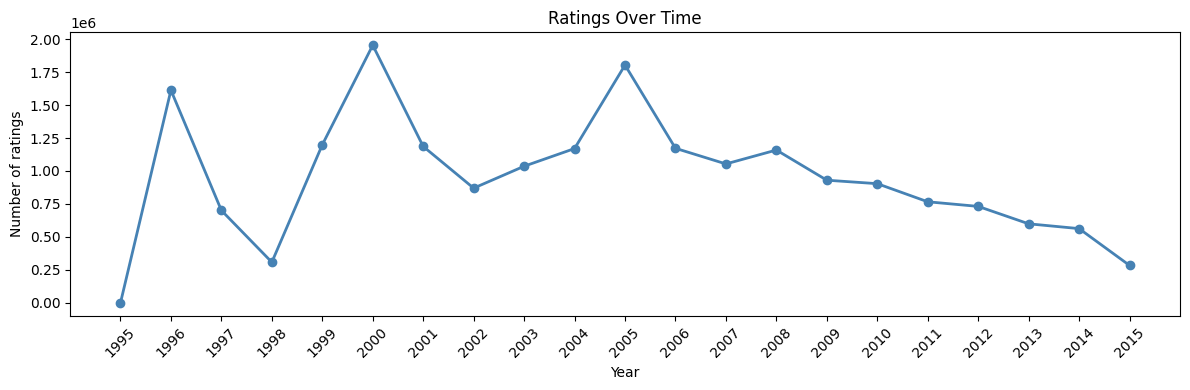

In [13]:
ratings['date'] = pd.to_datetime(ratings['timestamp'])
ratings['year'] = ratings['date'].dt.year

ratings_per_year = ratings.groupby('year')['rating'].count()

print(ratings_per_year)

plt.figure(figsize=(12, 4))
plt.plot(ratings_per_year.index, ratings_per_year.values,
         color='steelblue', marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of ratings')
plt.title('Ratings Over Time')
plt.xticks(ratings_per_year.index, rotation=45)
plt.tight_layout()
plt.show()

## Tag Analysis

A quick look at the least used tags confirms what the numbers already suggested —
user generated tags are gloriously noisy. Single-use tags range from encoding
errors to genuine film criticism ("Dogshit", "Hell naw") to complete nonsense
("Botox", "Bobo").

With 38,643 unique tags applied by only 5.6% of users, the signal-to-noise
ratio is simply too low to rely on for structured features. We'll use genome
scores as our primary content signal — curated, consistent, and mercifully
free of "cocaine-Disney" tag (whatever this means" XD

In [23]:
tags = pd.read_csv('/content/drive/MyDrive/archive/tag.csv')

print(f"Total tag applications: {len(tags):,}")
print(f"Unique tags: {tags['tag'].nunique():,}")
print(f"Users who applied tags: {tags['userId'].nunique():,}")

# Most popular tags
print("\nTop 20 most used tags:")
print(tags['tag'].value_counts().head(20))
print("\nTop 20 least used tags:")
print(tags['tag'].value_counts().tail(20))

Total tag applications: 465,564
Unique tags: 38,643
Users who applied tags: 7,801

Top 20 most used tags:
tag
sci-fi                3384
based on a book       3281
atmospheric           2917
comedy                2779
action                2657
surreal               2427
BD-R                  2334
twist ending          2323
funny                 2072
dystopia              1991
stylized              1941
quirky                1906
dark comedy           1899
classic               1769
psychology            1754
fantasy               1703
time travel           1549
romance               1534
visually appealing    1509
disturbing            1487
Name: count, dtype: int64

Top 20 least used tags:
tag
AlmodÃƒÂ³var                                                            1
circle k                                                                1
This movie should have been called \\"How Cocaine Ruined Disney\"\""    1
Disguises                                                               1